# U-Net 이미지 세그멘테이션
## 데이터셋: Oxford-IIIT Pet Dataset

### 개요
- **U-Net**: Ronneberger et al. (2015) 원본 구조 기반 구현
- **Encoder**: ImageNet 사전학습 VGG16 가중치 사용 (TernausNet 방식)
- **데이터셋**: Oxford-IIIT Pet — 37종 반려동물, 픽셀 단위 마스크
- **태스크**: 3-class 세그멘테이션 (전경 / 배경 / 경계)

> **참고**: 원본 U-Net 논문은 의료 이미지에서 from scratch 학습을 했지만,
> 실제 응용에서는 ImageNet pretrained encoder 방식(TernausNet, 2018)이 표준입니다.

In [1]:
# 필요한 패키지 설치
!pip install -q segmentation-models-pytorch albumentations

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')  # Mac(MPS) 미지원 연산 자동 우회

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet

import segmentation_models_pytorch as smp

# 재현성을 위한 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# 장치 선택: CUDA > MPS(애플 GPU) > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'사용 장치: {device} ({torch.cuda.get_device_name(0)})')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'사용 장치: {device} (Apple Silicon GPU)')
else:
    device = torch.device('cpu')
    print(f'사용 장치: {device}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/namun/.pyenv/versions/3.10.13/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/namun/.pyenv/versions/3.10.13/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/namun/dev/A7608-2026-1-vision-dl/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/namun/dev/A7608-2026-1-vision-dl/.venv/lib/python3.10/site-packages/traitlets/confi

사용 장치: cpu


## 2. 데이터셋 준비

Oxford-IIIT Pet Dataset의 세그멘테이션 마스크는 3가지 값을 가집니다:
- **1**: 전경 (반려동물 영역)
- **2**: 배경
- **3**: 경계 (윤곽선 부근)

학습 편의상 0-indexed로 변환합니다: 0(전경), 1(배경), 2(경계)

In [3]:
# 하이퍼파라미터 설정
IMAGE_SIZE    = 256    # 입력 이미지 크기 (256x256)
BATCH_SIZE    = 8      # 배치 크기 (GPU 메모리 부족 시 4로 줄이세요)
NUM_EPOCHS    = 10     # 학습 에폭 수 (더 좋은 결과는 20~30)
LEARNING_RATE = 1e-4   # 학습률
NUM_CLASSES   = 3      # 클래스 수: 전경 / 배경 / 경계
DATA_DIR      = './data'

In [ ]:
class PetSegmentationDataset(Dataset):
    """
    Oxford-IIIT Pet Dataset 세그멘테이션용 커스텀 데이터셋.
    torchvision의 OxfordIIITPet을 내부적으로 사용합니다.
    """
    def __init__(self, root, split='trainval', image_size=256, download=True):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',  # 픽셀 단위 마스크 사용
            download=download
        )
        self.image_size = image_size

        # 이미지 전처리: 리사이즈 -> 텐서 변환 -> ImageNet 정규화
        self.img_transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
        ])

        # 최근접 이웃 보간
        self.mask_transform = T.Resize(
            (image_size, image_size),
            interpolation=T.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image = self.img_transform(image)
        mask  = self.mask_transform(mask)
        mask  = torch.tensor(np.array(mask), dtype=torch.long)
        mask  = mask - 1
        return image, mask


print('데이터셋 다운로드 중... (첫 실행 시 약 800MB, 수 분 소요)')
train_dataset = PetSegmentationDataset(DATA_DIR, split='trainval', image_size=IMAGE_SIZE)
test_dataset  = PetSegmentationDataset(DATA_DIR, split='test',     image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'학습 샘플 수 : {len(train_dataset)}')
print(f'테스트 샘플 수: {len(test_dataset)}')

데이터셋 다운로드 중... (첫 실행 시 약 800MB, 수 분 소요)


  0%|          | 0/791918971 [00:00<?, ?it/s]

/tmp/ipykernel_27275/1680307690.py:37: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])
/tmp/ipykernel_27275/1680307690.py:37: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])
/tmp/ipykernel_27275/1680307690.py:37: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])
/tmp/ipykernel_27275/1680307690.py:37: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from

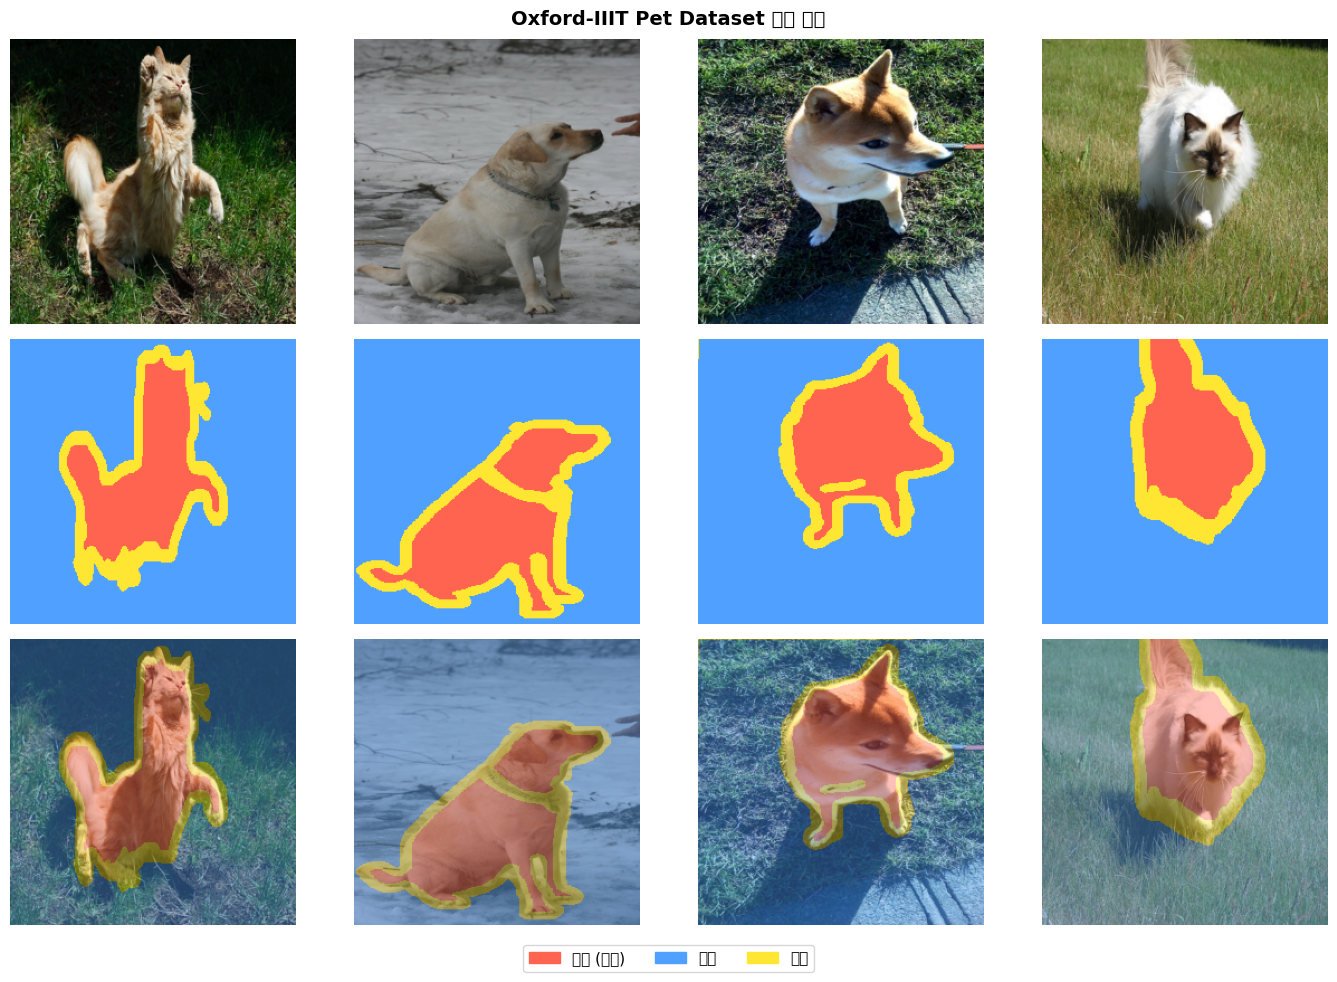

In [ ]:
# 시각화 헬퍼 함수
def denormalize(tensor):
    """ImageNet 정규화 역변환 (시각화용)"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# 전경(주황), 배경(파랑), 경계(노랑)
COLORS = np.array([[255, 100, 80], [80, 160, 255], [255, 230, 50]], dtype=np.uint8)
CLASS_NAMES = ['전경 (동물)', '배경', '경계']

def mask_to_rgb(mask_tensor):
    """정수 마스크(H,W) -> RGB 이미지(H,W,3)"""
    mask_np = np.clip(mask_tensor.numpy(), 0, NUM_CLASSES - 1)
    return COLORS[mask_np]


# 데이터 샘플 시각화
images, masks = next(iter(train_loader))
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Oxford-IIIT Pet Dataset 샘플 확인', fontsize=14, fontweight='bold')

row_labels = ['원본 이미지', '정답 마스크', '오버레이']
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11)

for i in range(4):
    img_np    = denormalize(images[i]).permute(1, 2, 0).numpy()
    mask_rgb  = mask_to_rgb(masks[i])
    overlay   = img_np * 0.6 + mask_rgb / 255.0 * 0.4
    axes[0, i].imshow(img_np);   axes[0, i].axis('off')
    axes[1, i].imshow(mask_rgb); axes[1, i].axis('off')
    axes[2, i].imshow(overlay);  axes[2, i].axis('off')

patches = [mpatches.Patch(color=COLORS[c]/255, label=CLASS_NAMES[c]) for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 3. U-Net 모델 정의

### 원본 U-Net 구조 (Ronneberger et al., 2015)
- **Encoder (수축 경로)**: Conv -> Conv -> MaxPool 반복 블록
- **Bottleneck**: 가장 깊은 레이어
- **Decoder (확장 경로)**: Upsample + Skip Connection + Conv -> Conv 블록
- **출력**: 픽셀별 클래스 확률

### 이 구현의 특징
- Encoder를 **VGG16 (ImageNet pretrained)** 으로 교체 -> 빠른 수렴
- Decoder 구조는 원본 U-Net과 동일
- `segmentation_models_pytorch` 라이브러리 활용

In [ ]:
# U-Net 모델 생성
# encoder_name    : 인코더 백본 (VGG16, ImageNet 사전학습)
# encoder_weights : 사전학습 가중치 ('imagenet')
# in_channels     : 입력 채널 (RGB = 3)
# classes         : 출력 클래스 수 (전경/배경/경계 = 3)
model = smp.Unet(
    encoder_name    = 'vgg16',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = NUM_CLASSES,
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'전체 파라미터 수  : {total_params:,}')
print(f'학습 가능 파라미터: {trainable_params:,}')

전체 파라미터 수  : 23,748,531
학습 가능 파라미터: 23,748,531


In [ ]:
# CrossEntropyLoss: 다중 클래스 픽셀 분류에 가장 일반적
criterion = nn.CrossEntropyLoss(ignore_index=255)

# Adam: 세그멘테이션 태스크에서 널리 사용
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau: 검증 손실 정체시 학습률 절반으로 감소
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)


def compute_iou(preds, labels, num_classes=NUM_CLASSES, ignore_index=255):
    """
    mean IoU (Intersection over Union) 계산
    세그멘테이션 품질의 표준 평가 지표
    IoU = TP / (TP + FP + FN)
    """
    iou_list = []
    preds  = preds.view(-1)
    labels = labels.view(-1)
    valid  = labels != ignore_index
    preds, labels = preds[valid], labels[valid]
    for cls in range(num_classes):
        pred_c  = preds  == cls
        label_c = labels == cls
        inter = (pred_c & label_c).sum().float()
        union = (pred_c | label_c).sum().float()
        if union == 0:
            continue
        iou_list.append((inter / union).item())
    return np.mean(iou_list) if iou_list else 0.0

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """한 에폭 학습용 코드, 이걸 반복해서 학습하는 것"""
    model.train()
    total_loss = 0.0
    total_iou  = 0.0
    for batch_idx, (images, masks) in enumerate(loader):
        images = images.to(device)       # (B, 3, H, W)
        masks  = masks.to(device)        # (B, H, W)
        outputs = model(images)          # (B, num_classes, H, W)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        preds     = outputs.argmax(dim=1)
        batch_iou = compute_iou(preds.cpu(), masks.cpu())
        total_loss += loss.item()
        total_iou  += batch_iou
        if (batch_idx + 1) % 10 == 0:
            print(f'  배치 [{batch_idx+1}/{len(loader)}]  '
                  f'손실: {loss.item():.4f}  IoU: {batch_iou:.4f}')
    return total_loss / len(loader), total_iou / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """검증/테스트 평가"""
    model.eval()
    total_loss = 0.0
    total_iou  = 0.0
    for images, masks in loader:
        images  = images.to(device)
        masks   = masks.to(device)
        outputs = model(images)
        loss    = criterion(outputs, masks)
        preds   = outputs.argmax(dim=1)
        total_loss += loss.item()
        total_iou  += compute_iou(preds.cpu(), masks.cpu())
    return total_loss / len(loader), total_iou / len(loader)

In [ ]:
history  = {'train_loss': [], 'test_loss': [], 'train_iou': [], 'test_iou': []}
best_iou = 0.0

print('=' * 60)
print(f' U-Net 학습 시작  |  총 {NUM_EPOCHS} 에폭  |  장치: {device}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\n[에폭 {epoch}/{NUM_EPOCHS}]')
    train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss,  test_iou  = evaluate(model, test_loader, criterion, device)
    scheduler.step(test_loss)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_iou'].append(train_iou)
    history['test_iou'].append(test_iou)
    if test_iou > best_iou:
        best_iou = test_iou
        torch.save(model.state_dict(), 'best_unet_pet.pth')
        print(f'  성능 최고 모델을 저장 (test IoU: {best_iou:.4f})')
    print(f'  학습  -- 손실: {train_loss:.4f} | mIoU: {train_iou:.4f}')
    print(f'  테스트 -- 손실: {test_loss:.4f} | mIoU: {test_iou:.4f}')

print('\n학습 완료!')
print(f'최고 테스트 mIoU: {best_iou:.4f}')

 U-Net 학습 시작  |  총 10 에폭  |  장치: cuda

[에폭 1/10]
  배치 [10/460]  손실: 1.3063  IoU: 0.1715
  배치 [20/460]  손실: 1.1921  IoU: 0.2188
  배치 [30/460]  손실: 1.0028  IoU: 0.2841
  배치 [40/460]  손실: 0.8821  IoU: 0.3857
  배치 [50/460]  손실: 0.6874  IoU: 0.5516
  배치 [60/460]  손실: 0.6332  IoU: 0.5791
  배치 [70/460]  손실: 0.5614  IoU: 0.6473
  배치 [80/460]  손실: 0.4887  IoU: 0.6860
  배치 [90/460]  손실: 0.4880  IoU: 0.6420
  배치 [100/460]  손실: 0.4322  IoU: 0.7133
  배치 [110/460]  손실: 0.4048  IoU: 0.7296
  배치 [120/460]  손실: 0.4528  IoU: 0.6632
  배치 [130/460]  손실: 0.3755  IoU: 0.7391
  배치 [140/460]  손실: 0.3796  IoU: 0.7080
  배치 [150/460]  손실: 0.3514  IoU: 0.7518
  배치 [160/460]  손실: 0.3314  IoU: 0.7421
  배치 [170/460]  손실: 0.2913  IoU: 0.7667
  배치 [180/460]  손실: 0.3199  IoU: 0.7391
  배치 [190/460]  손실: 0.2699  IoU: 0.7812
  배치 [200/460]  손실: 0.2985  IoU: 0.7539
  배치 [210/460]  손실: 0.3515  IoU: 0.7154
  배치 [220/460]  손실: 0.2670  IoU: 0.7735
  배치 [230/460]  손실: 0.3858  IoU: 0.7268
  배치 [240/460]  손실: 0.2648  IoU: 0.7637


/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 54253 (\N{HANGUL SYLLABLE POG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27275/265045754.py:19: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_lay

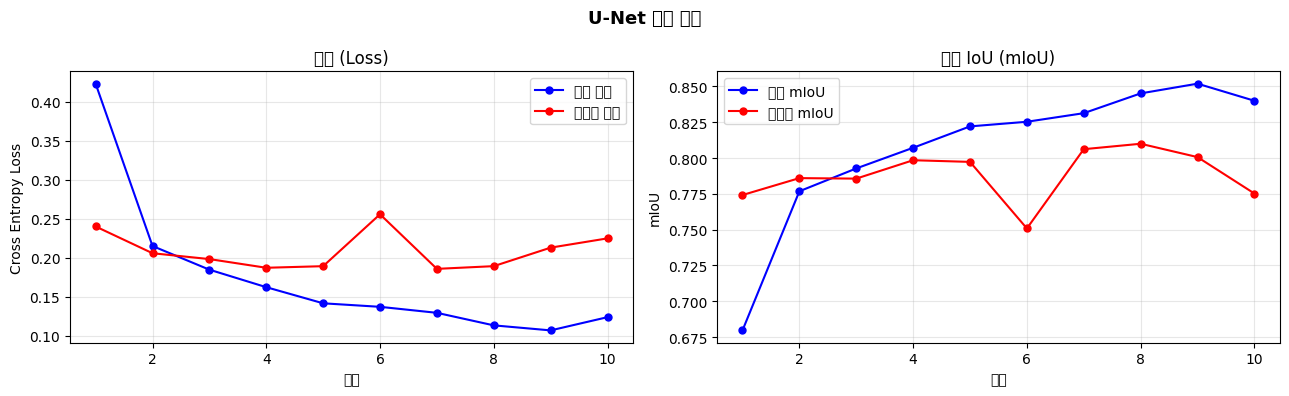

In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('U-Net 학습 곡선', fontsize=13, fontweight='bold')

ax1.plot(epochs, history['train_loss'], 'b-o', label='학습 손실', markersize=5)
ax1.plot(epochs, history['test_loss'],  'r-o', label='테스트 손실', markersize=5)
ax1.set_title('손실 (Loss)')
ax1.set_xlabel('에폭')
ax1.set_ylabel('Cross Entropy Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_iou'], 'b-o', label='학습 mIoU', markersize=5)
ax2.plot(epochs, history['test_iou'],  'r-o', label='테스트 mIoU', markersize=5)
ax2.set_title('평균 IoU (mIoU)')
ax2.set_xlabel('에폭')
ax2.set_ylabel('mIoU')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

최고 성능 모델 로드 완료


/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipykernel_27275/3464124029.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.04, 1, 1])
/tmp/ipyker

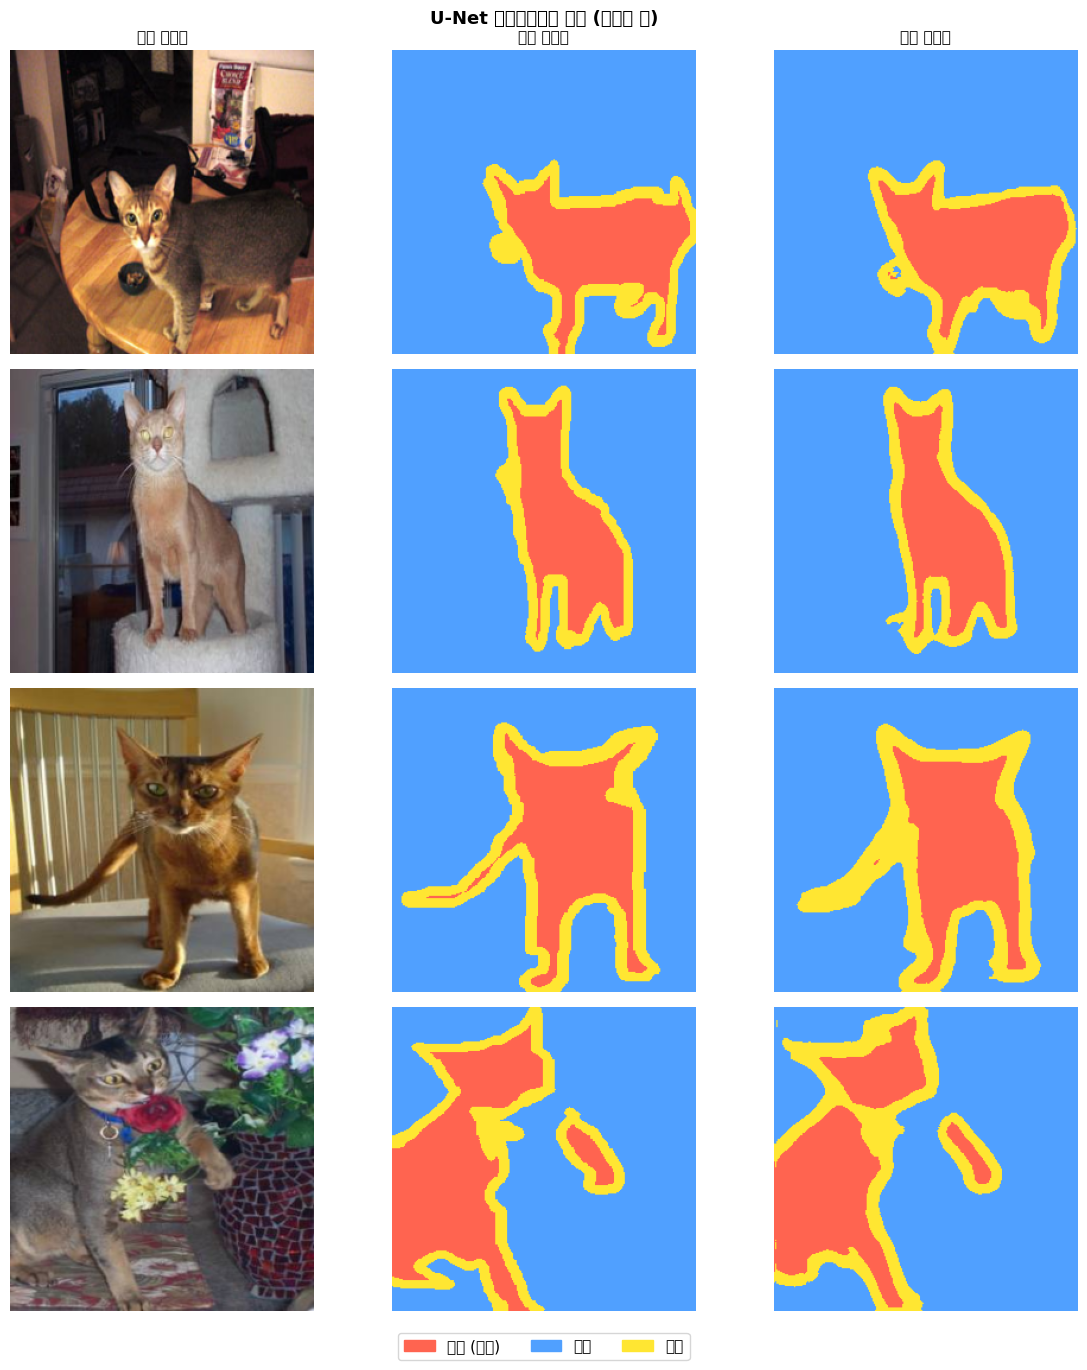

In [ ]:
# 최고 성능 모델 로드
model.load_state_dict(torch.load('best_unet_pet.pth', map_location=device))
model.eval()
print('최고 성능 모델 로드 완료')

images, masks = next(iter(test_loader))
with torch.no_grad():
    outputs = model(images.to(device))
    preds   = outputs.argmax(dim=1).cpu()

n_samples = min(4, BATCH_SIZE)
fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3.5))
fig.suptitle('U-Net 세그멘테이션 결과 (테스트 셋)', fontsize=13, fontweight='bold')
for ax, title in zip(axes[0], ['원본 이미지', '정답 마스크', '예측 마스크']):
    ax.set_title(title, fontsize=11, fontweight='bold')

for i in range(n_samples):
    img_show  = denormalize(images[i]).permute(1, 2, 0).numpy()
    gt_show   = mask_to_rgb(masks[i])
    pred_show = mask_to_rgb(preds[i])
    iou_val   = compute_iou(preds[i].unsqueeze(0), masks[i].unsqueeze(0))
    axes[i, 0].imshow(img_show);  axes[i, 0].axis('off')
    axes[i, 1].imshow(gt_show);   axes[i, 1].axis('off')
    axes[i, 2].imshow(pred_show); axes[i, 2].axis('off')
    axes[i, 2].set_xlabel(f'IoU: {iou_val:.3f}', fontsize=10)

patches = [mpatches.Patch(color=COLORS[c]/255, label=CLASS_NAMES[c]) for c in range(NUM_CLASSES)]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [ ]:
final_loss, final_iou = evaluate(model, test_loader, criterion, device)
print("=" * 40)
print("      최종 테스트 성능")
print("=" * 40)
print(f"  Cross Entropy Loss : {final_loss:.4f}")
print(f"  mean IoU (mIoU)   : {final_iou:.4f}  ({final_iou*100:.1f}%)")
print("=" * 40)

# 클래스별 IoU
intersection = torch.zeros(NUM_CLASSES)
union        = torch.zeros(NUM_CLASSES)

model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        outputs = model(images.to(device))
        preds   = outputs.argmax(dim=1).cpu().view(-1)
        labels  = masks.view(-1)
        valid   = labels != 255
        preds, labels = preds[valid], labels[valid]
        for cls in range(NUM_CLASSES):
            pred_c  = preds  == cls
            label_c = labels == cls
            intersection[cls] += (pred_c & label_c).sum().float()
            union[cls]        += (pred_c | label_c).sum().float()

print("클래스별 IoU:")
for cls in range(NUM_CLASSES):
    iou = (intersection[cls] / union[cls]).item() if union[cls] > 0 else 0.0
    print(f"  {CLASS_NAMES[cls]:<15}: {iou:.4f}  ({iou*100:.1f}%)")


      최종 테스트 성능
  Cross Entropy Loss : 0.1892
  mean IoU (mIoU)   : 0.8100  (81.0%)
클래스별 IoU:
  전경 (동물)        : 0.8827  (88.3%)
  배경             : 0.9392  (93.9%)
  경계             : 0.6104  (61.0%)


## 5. 커스텀 이미지 추론 (선택)

직접 이미지를 업로드하여 세그멘테이션 결과를 확인할 수 있습니다.

이미지 파일을 업로드하세요 (jpg, png 등)


Saving SjITKjha1tDoYMsqy2p7WG7gp23gkw.jpg to SjITKjha1tDoYMsqy2p7WG7gp23gkw (2).jpg
SjITKjha1tDoYMsqy2p7WG7gp23gkw (2).jpg 추론 중...


/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_27275/825649462.py:24: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.08, 1, 1])
/tmp/ipykernel_2

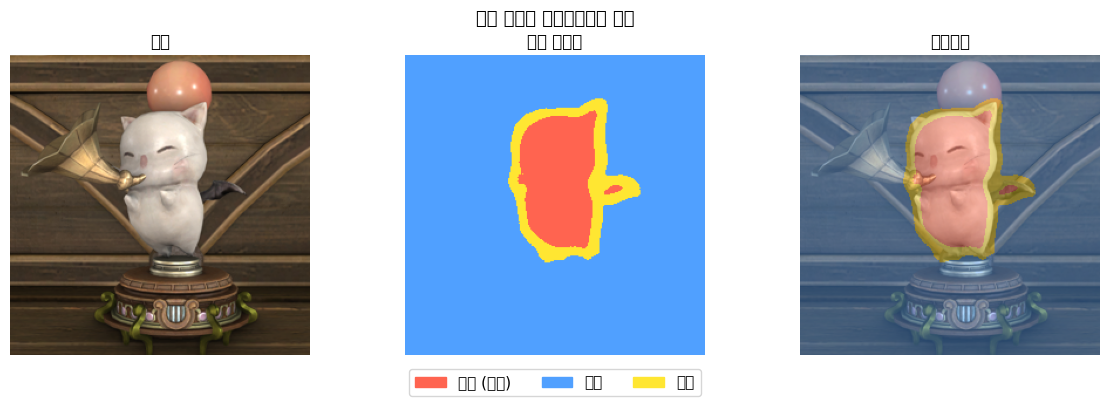

In [ ]:
from google.colab import files

def predict_single_image(image_path, model, device, image_size=IMAGE_SIZE):
    transform = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert('RGB')
    inp = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        pred = model(inp).argmax(dim=1)[0].cpu()
    img_show  = img.resize((image_size, image_size))
    pred_rgb  = mask_to_rgb(pred)
    overlay   = np.array(img_show) / 255.0 * 0.6 + pred_rgb / 255.0 * 0.4
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('단일 이미지 세그멘테이션 결과', fontsize=13, fontweight='bold')
    axes[0].imshow(img_show); axes[0].set_title('원본'); axes[0].axis('off')
    axes[1].imshow(pred_rgb); axes[1].set_title('예측 마스크'); axes[1].axis('off')
    axes[2].imshow(overlay);  axes[2].set_title('오버레이'); axes[2].axis('off')
    patches = [mpatches.Patch(color=COLORS[c]/255, label=CLASS_NAMES[c]) for c in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=11)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

print('이미지 파일을 업로드하세요 (jpg, png 등)')
uploaded = files.upload()
for filename in uploaded.keys():
    print(f'{filename} 추론 중...')
    predict_single_image(filename, model, device)